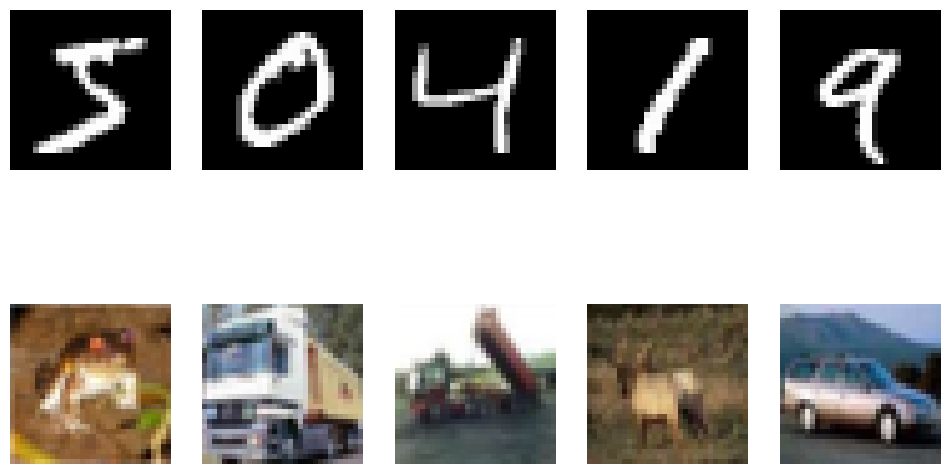

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("student_micro_dataset2.npz")
#print(data["fashion"][10])
# plt.imshow(data["fashion"][15], cmap='gray')
# plt.axis('off')

mnist_5=data["mnist"][:5]
cifar_5=data["cifar"][:5]
fig, axes = plt.subplots(2, 5, figsize=(12, 7))

for i in range(5):
    axes[0,i].imshow(mnist_5[i], cmap='gray')
    axes[0,i].axis('off')
    
    axes[1,i].imshow(cifar_5[i], cmap='gray')
    axes[1,i].axis('off')
plt.show()

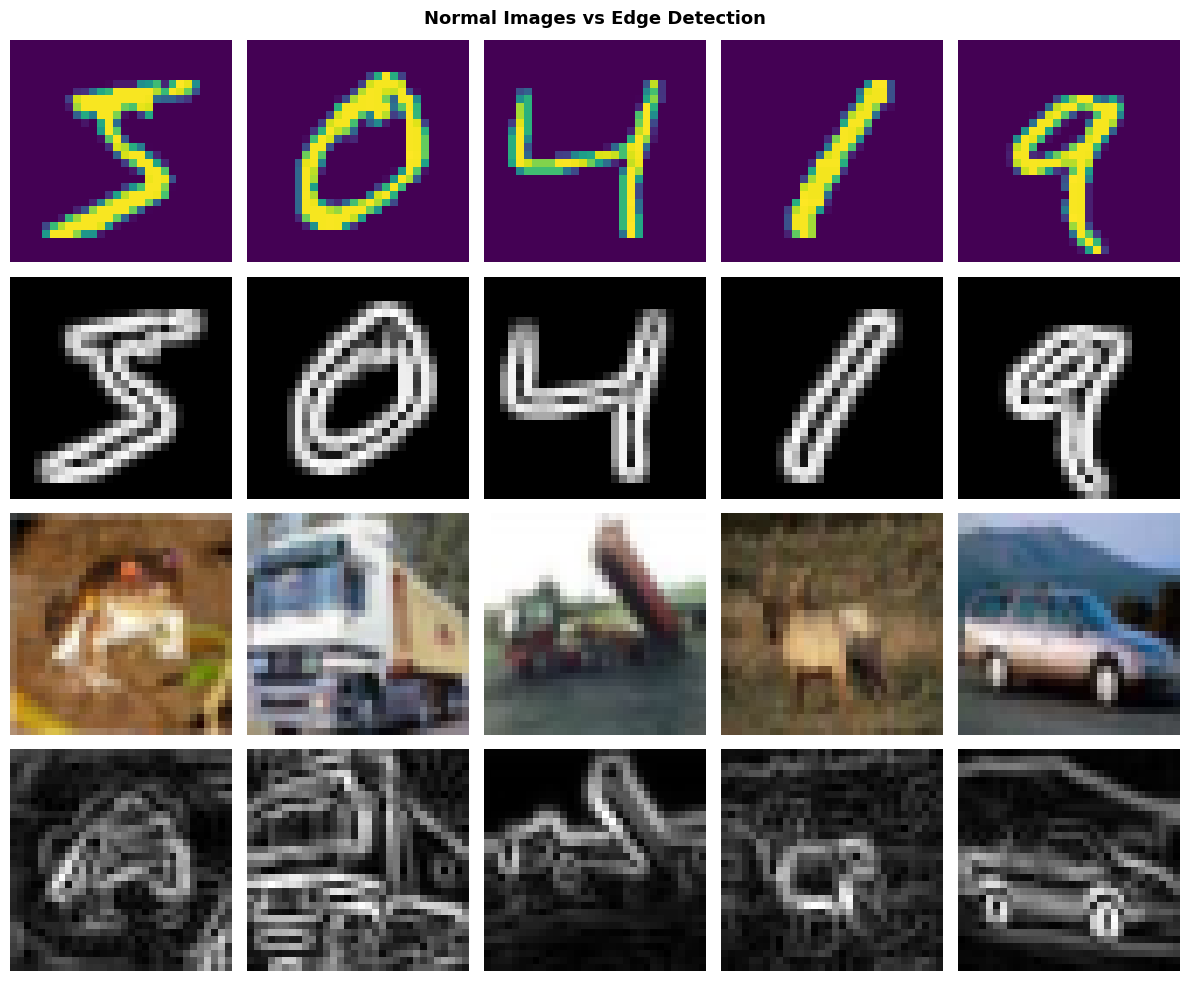

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import sobel

data = np.load("student_micro_dataset2.npz")

mnist_5 = data["mnist"][:5]
cifar_5 = data["cifar"][:5]

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for i in range(5):
    axes[0, i].imshow(mnist_5[i])
    axes[0, i].axis('off')

    axes[1, i].imshow(sobel(mnist_5[i]), cmap='gray')
    axes[1, i].axis('off')

    axes[2, i].imshow(cifar_5[i])
    axes[2, i].axis('off')

    cifar_gray = np.mean(cifar_5[i], axis=2) if cifar_5[i].ndim == 3 else cifar_5[i]
    axes[3, i].imshow(sobel(cifar_gray), cmap='gray')
    axes[3, i].axis('off')

plt.suptitle("Normal Images vs Edge Detection", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
import torch
import torch.nn as nn

conv=nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=2, padding=1)
x=torch.rand(1,1,8,8)
output=conv(x)
print("Output shape:", output.shape)

max_pool=nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool=nn.AvgPool2d(kernel_size=2, stride=2)

print("Max Pooling Output shape:", max_pool(output).shape)
print("Average Pooling Output shape:", avg_pool(output).shape)

Output shape: torch.Size([1, 1, 4, 4])
Max Pooling Output shape: torch.Size([1, 1, 2, 2])
Average Pooling Output shape: torch.Size([1, 1, 2, 2])


In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
import numpy as np

model=Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='valid', strides=1, input_shape=(32,32,3)),
    MaxPooling2D(pool_size=(2,2), strides=2), Flatten(), Dense(20, activation='sigmoid')
])

model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │       144,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,916 (566.08 KB)

 Trainable params: 144,916 (566.08 KB)

 Non-trainable params: 0 (0.00 B)